# Dataset Split Strategy

Before preprocessing and model development, the dataset must be divided into training and validation subsets.

Since BraTS2020 contains multiple MRI volumes for each patient, splitting must be performed at the patient level to avoid data leakage.

The resulting patient lists will be reused across the entire project, ensuring reproducibility and consistency.

## 1. Setup & Imports

In [1]:
from pathlib import Path
from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt

import json

## 2. Paths & Patient List

In [2]:
DATASET_PATH = Path(
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
)

patients = sorted(
    [
        patient
        for patient in DATASET_PATH.iterdir()
        if patient.is_dir()
    ]
)

print(f"Total Patients: {len(patients)}")

Total Patients: 369


### 2.1 Load Patient IDs

In [3]:
patient_ids = [patient.name for patient in patients]

patient_ids[:10]

['BraTS20_Training_001',
 'BraTS20_Training_002',
 'BraTS20_Training_003',
 'BraTS20_Training_004',
 'BraTS20_Training_005',
 'BraTS20_Training_006',
 'BraTS20_Training_007',
 'BraTS20_Training_008',
 'BraTS20_Training_009',
 'BraTS20_Training_010']

### 2.2 Uniqueness Check

In [4]:
print("Total IDs :", len(patient_ids))

print("Unique IDs:", len(set(patient_ids)))

assert len(patient_ids) == len(set(patient_ids))

print("✅ No duplicate patient IDs found.")

Total IDs : 369
Unique IDs: 369
✅ No duplicate patient IDs found.


## 3. Dataset Split — 70 / 15 / 15

### 3.1 Train+Val vs Test

In [5]:
train_val_ids, test_ids = train_test_split(

    patient_ids,

    test_size=0.15,

    random_state=42,

    shuffle=True
)

### 3.2 Train vs Validation

> `test_size=0.1765` → 15/85 ≈ 17.65% of train_val → final val ≈ 15% of total

In [6]:
train_ids, val_ids = train_test_split(

    train_val_ids,

    test_size=0.1765,

    random_state=42,

    shuffle=True
)

### 3.3 Split Sizes

In [7]:
print(f"Training Patients   : {len(train_ids)}")

print(f"Validation Patients : {len(val_ids)}")

print(f"Test Patients       : {len(test_ids)}")

Training Patients   : 257
Validation Patients : 56
Test Patients       : 56


## 4. Leakage Checks

In [8]:
assert len(set(train_ids) & set(val_ids)) == 0

assert len(set(train_ids) & set(test_ids)) == 0

assert len(set(val_ids) & set(test_ids)) == 0

print("✅ No Data Leakage Detected")

✅ No Data Leakage Detected


## 5. File Verification

### 5.1 Verify Function

In [9]:
expected_modalities = {
    "flair",
    "t1",
    "t1ce",
    "t2",
    "seg"
}

### 5.2 Run Verification on All Splits

In [10]:
def verify_patient(patient_id):

    patient_path = DATASET_PATH / patient_id

    files = list(patient_path.glob("*.nii"))

    if len(files) != 5:
        return False

    names = [f.name.lower() for f in files]

    checks = {
        "flair": any("flair" in n for n in names),
        "t1": any("_t1." in n for n in names),
        "t1ce": any("t1ce" in n for n in names),
        "t2": any("_t2." in n for n in names),
        "seg": any(("seg" in n) or ("segm" in n) for n in names),
    }

    return all(checks.values())

### 5.3 Assertions

In [11]:
train_check = all(
    verify_patient(pid)
    for pid in train_ids
)

val_check = all(
    verify_patient(pid)
    for pid in val_ids
)

test_check = all(
    verify_patient(pid)
    for pid in test_ids
)

print(f"Training Set   : {train_check}")

print(f"Validation Set : {val_check}")

print(f"Test Set       : {test_check}")

Training Set   : True
Validation Set : True
Test Set       : True


## 6. Save Split Files

### 6.1 Create Output Directory

In [12]:
assert train_check

assert val_check

assert test_check

print("✅ Every patient contains the expected MRI files.")

✅ Every patient contains the expected MRI files.


### 6.2 Save as TXT

In [13]:
split_dir = Path("/kaggle/working/datasets/splits")

split_dir.mkdir(
    parents=True,
    exist_ok=True
)

### 6.3 Save as CSV

In [14]:
with open(split_dir / "train_patients.txt", "w") as f:
    f.write("\n".join(train_ids))

with open(split_dir / "val_patients.txt", "w") as f:
    f.write("\n".join(val_ids))

with open(split_dir / "test_patients.txt", "w") as f:
    f.write("\n".join(test_ids))

## 7. Preview Splits

### 7.1 Training Patients

In [15]:
pd.DataFrame(
    {
        "PatientID": train_ids
    }
).to_csv(
    split_dir / "train_patients.csv",
    index=False
)

pd.DataFrame(
    {
        "PatientID": val_ids
    }
).to_csv(
    split_dir / "val_patients.csv",
    index=False
)

pd.DataFrame(
    {
        "PatientID": test_ids
    }
).to_csv(
    split_dir / "test_patients.csv",
    index=False
)

### 7.2 Validation Patients

In [16]:
print("Training Patients")

train_ids[:10]

Training Patients


['BraTS20_Training_317',
 'BraTS20_Training_174',
 'BraTS20_Training_262',
 'BraTS20_Training_042',
 'BraTS20_Training_252',
 'BraTS20_Training_063',
 'BraTS20_Training_208',
 'BraTS20_Training_352',
 'BraTS20_Training_329',
 'BraTS20_Training_002']

### 7.3 Test Patients

In [17]:
print("Validation Patients")

val_ids[:10]

Validation Patients


['BraTS20_Training_361',
 'BraTS20_Training_074',
 'BraTS20_Training_101',
 'BraTS20_Training_335',
 'BraTS20_Training_168',
 'BraTS20_Training_111',
 'BraTS20_Training_150',
 'BraTS20_Training_222',
 'BraTS20_Training_309',
 'BraTS20_Training_055']

In [18]:
print("Test Patients")

test_ids[:10]

Test Patients


['BraTS20_Training_327',
 'BraTS20_Training_034',
 'BraTS20_Training_016',
 'BraTS20_Training_346',
 'BraTS20_Training_058',
 'BraTS20_Training_240',
 'BraTS20_Training_077',
 'BraTS20_Training_120',
 'BraTS20_Training_306',
 'BraTS20_Training_127']

# Save Dataset Split as JSON

In addition to TXT and CSV files, the dataset split is also stored in JSON format.

A single JSON file simplifies loading the dataset partitions in later modules such as:

- dataset.py
- preprocessing.py
- train.py
- predict.py

In [19]:
dataset_split = {

    "train": train_ids,

    "validation": val_ids,

    "test": test_ids

}

In [20]:
with open(

    split_dir / "dataset_split.json",

    "w"

) as f:

    json.dump(

        dataset_split,

        f,

        indent=4

    )

In [21]:
with open(

    split_dir / "dataset_split.json",

    "r"

) as f:

    loaded_split = json.load(f)

loaded_split.keys()

dict_keys(['train', 'validation', 'test'])

In [22]:
print("Training Patients")

print(loaded_split["train"][:5])

print()

print("Validation Patients")

print(loaded_split["validation"][:5])

print()

print("Test Patients")

print(loaded_split["test"][:5])

Training Patients
['BraTS20_Training_317', 'BraTS20_Training_174', 'BraTS20_Training_262', 'BraTS20_Training_042', 'BraTS20_Training_252']

Validation Patients
['BraTS20_Training_361', 'BraTS20_Training_074', 'BraTS20_Training_101', 'BraTS20_Training_335', 'BraTS20_Training_168']

Test Patients
['BraTS20_Training_327', 'BraTS20_Training_034', 'BraTS20_Training_016', 'BraTS20_Training_346', 'BraTS20_Training_058']


In [23]:
split_summary = pd.DataFrame({

    "Subset":[

        "Training",

        "Validation",

        "Test"

    ],

    "Patients":[

        len(train_ids),

        len(val_ids),

        len(test_ids)

    ]

})

split_summary["Percentage"] = (

    split_summary["Patients"]

    / len(patient_ids)

    *100

)

split_summary

,Subset,Patients,Percentage
0,Training,257,69.647696
1,Validation,56,15.176152
2,Test,56,15.176152


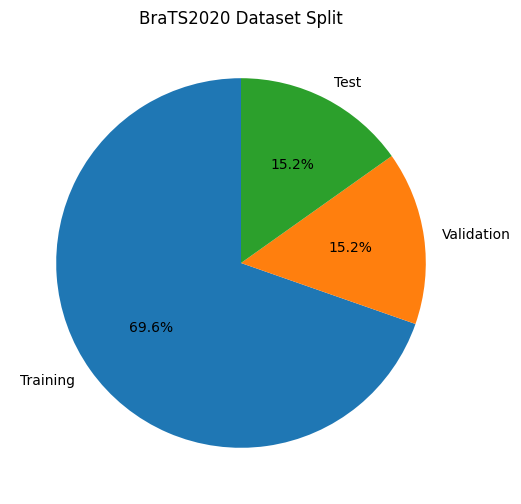

In [24]:
plt.figure(figsize=(6,6))

plt.pie(

    split_summary["Patients"],

    labels=split_summary["Subset"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("BraTS2020 Dataset Split")

plt.show()

In [25]:
split_summary.to_csv(

    split_dir / "split_summary.csv",

    index=False
)

In [26]:
print("="*60)

print("BraTS2020 Dataset Split Completed")

print("="*60)

print(f"Total Patients : {len(patient_ids)}")

print(f"Training       : {len(train_ids)}")

print(f"Validation     : {len(val_ids)}")

print(f"Test           : {len(test_ids)}")

print()

print("Output Directory")

print(split_dir)

print()

print("Generated Files")

for file in sorted(split_dir.iterdir()):

    print("-", file.name)

print()

print("✅ Dataset Split Completed Successfully")

BraTS2020 Dataset Split Completed
Total Patients : 369
Training       : 257
Validation     : 56
Test           : 56

Output Directory
/kaggle/working/datasets/splits

Generated Files
- dataset_split.json
- split_summary.csv
- test_patients.csv
- test_patients.txt
- train_patients.csv
- train_patients.txt
- val_patients.csv
- val_patients.txt

✅ Dataset Split Completed Successfully


# Engineering Decision

The BraTS2020 dataset has been permanently divided into independent Training, Validation, and Test subsets.

The split is performed at the patient level to eliminate data leakage.

The generated split files will be reused by:

- src/cv_module/dataset.py
- src/cv_module/preprocessing.py
- src/cv_module/train.py
- src/cv_module/predict.py

This guarantees:

- Reproducibility
- Fair evaluation
- Consistent experiments
- Reliable deployment